# Market Data Analysis

## Importing Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## Loading Dataset

In [50]:
df=pd.read_csv("marketing_campaign_data.csv")

### Summary of the dataset

In [51]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [52]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null 

In [54]:
df.nunique()

ID                     56000
Year_Birth                61
Education                  5
Marital_Status             8
Income                 50621
Kidhome                    3
Teenhome                   3
Dt_Customer              700
Recency                  100
MntWines                1492
MntFruits                200
MntMeatProducts         1336
MntFishProducts          260
MntSweetProducts         259
MntGoldProds             344
NumDealsPurchases         16
NumWebPurchases           16
NumCatalogPurchases       15
NumStorePurchases         14
NumWebVisitsMonth         11
AcceptedCmp3               2
AcceptedCmp4               2
AcceptedCmp5               2
AcceptedCmp1               2
AcceptedCmp2               2
Response                   2
Complain                   2
Country                    8
dtype: int64

### Unique elements in Marital status

In [55]:
df["Marital_Status"].unique()

array(['Together', 'Single', 'Married', 'Divorced', 'YOLO', 'Alone',
       'Widow', 'Absurd'], dtype=object)

In [56]:
df['Marital_Status'].value_counts()

Marital_Status
Together    17703
Married     13686
Single      12238
Divorced     6459
Widow        3540
Alone         911
Absurd        733
YOLO          730
Name: count, dtype: int64

In [57]:
map1 = {'Married': 'Married','Together': 'Married', 'Single': 'Single', 'Divorced':'Divorced', 'Widow':'Widowed', 'Alone':'Single',
        'Absurd': 'Single', 'YOLO': 'Single'}

In [58]:
df['Marital_Status'] = df['Marital_Status'].map(map1)
print(df['Marital_Status'].value_counts())

Marital_Status
Married     31389
Single      14612
Divorced     6459
Widowed      3540
Name: count, dtype: int64


### Unique elements in Education

In [59]:
df["Education"].unique()

array(['Graduation', 'Master', '2n Cycle', 'Basic', 'PhD'], dtype=object)

In [60]:
df["Education"].value_counts()

Education
Graduation    22741
PhD           12581
Master        10530
2n Cycle       5966
Basic          4182
Name: count, dtype: int64

### Ensured the datatype of Dt_Customer

In [61]:
df['Dt_Customer'].dtype

dtype('O')

In [62]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

In [63]:
df['Dt_Customer'].head()

0   2012-11-17
1   2013-04-10
2   2014-01-11
3   2014-06-18
4   2014-05-20
Name: Dt_Customer, dtype: datetime64[ns]

### Added required columns

In [64]:
df['Tenure_days'] = (pd.to_datetime('2024-01-01') - df['Dt_Customer']).dt.days

In [65]:
print(df['Tenure_days'].describe())

count    56000.000000
mean      3790.687286
std        220.316266
min       3473.000000
25%       3584.000000
50%       3787.000000
75%       3994.000000
max       4172.000000
Name: Tenure_days, dtype: float64


In [66]:
df['Age'] = 2024 - df['Year_Birth']
df['Total_Amt'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)
df['Childrens'] = df['Kidhome'] + df['Teenhome']
df['Campaigns_Accepted'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)
df['Is_Parent'] = df['Childrens'].apply(lambda x: 'Parent' if x > 0 else 'Non-Parent')

In [67]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Response,Complain,Country,Tenure_days,Age,Total_Amt,Total_Purchases,Childrens,Campaigns_Accepted,Is_Parent
0,342199,1985,Graduation,Married,59011.7,1,0,2012-11-17,3,0,...,0,0,Spain,4062,39,69,10,1,0,Parent
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,Spain,3918,49,39,3,2,0,Parent
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,0,Australia,3642,46,1512,9,0,0,Non-Parent
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,0,Spain,3484,48,478,15,1,0,Parent
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,0,0,Canada,3513,43,330,8,2,0,Parent


In [68]:
def age_group(age):
    if   age < 18 : return 'Teen'
    elif age < 30 : return 'Young Adult'
    elif age < 50 : return 'Middle Aged'
    elif age < 65 : return 'Senior'
    else          : return 'Elderly'

df['Age_Group'] = df['Age'].apply(age_group)

In [69]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Country,Tenure_days,Age,Total_Amt,Total_Purchases,Childrens,Campaigns_Accepted,Is_Parent,Age_Group
0,342199,1985,Graduation,Married,59011.7,1,0,2012-11-17,3,0,...,0,Spain,4062,39,69,10,1,0,Parent,Middle Aged
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,Spain,3918,49,39,3,2,0,Parent,Middle Aged
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,Australia,3642,46,1512,9,0,0,Non-Parent,Middle Aged


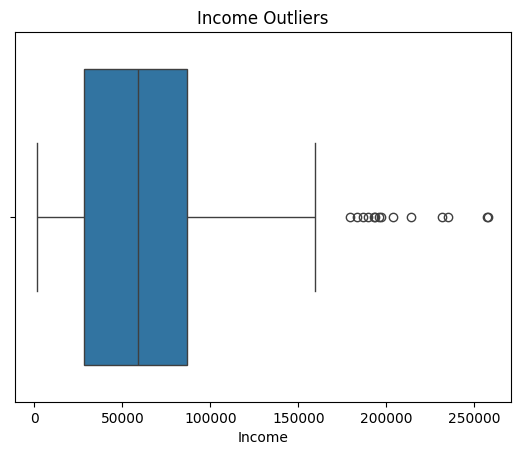

In [70]:
sns.boxplot(x=df['Income'])
plt.title("Income Outliers")
plt.show()

### Removed Outliers in income

In [71]:
df['Income'].fillna(df['Income'].median(), inplace=True)

In [72]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df['Income'] >= lower_limit) & (df['Income'] <= upper_limit)]
print(f"Income outliers removed. New shape: {df.shape}")

Income outliers removed. New shape: (55986, 36)


In [73]:
def income_group(income):
    if   income <= 20000  : return 'Low'
    elif income <= 30000  : return 'Lower Middle'
    elif income <= 75000  : return 'Middle'
    elif income <= 120000 : return 'Upper Middle'
    else                  : return 'High'

df['Income_Group'] = df['Income'].apply(income_group)

In [74]:
spend_90th = df["Total_Amt"].quantile(0.90)

def assign_segment(row):
    if row["Total_Amt"] > spend_90th:
        return "High Spender"
    elif row["Income"] > 75000:
        return "High Income"
    elif row["Response"] == 1:
        return "Campaign Responder"
    elif row["NumWebVisitsMonth"] > 5:
        return "High Web Engagement"
    elif row["Childrens"] > 0:
        return "Family Customer"
    elif row["Age"] < 30:
        return "Young Customer"
    else:
        return "General"

df["Segment"] = df.apply(assign_segment, axis=1)

print(df["Segment"].value_counts())

Segment
High Web Engagement    19722
High Income            15633
Family Customer         8864
High Spender            5596
Campaign Responder      3302
General                 2822
Young Customer            47
Name: count, dtype: int64


In [75]:
df.to_csv("Final_dataset.csv",index=False)

In [76]:
pd.read_csv('Final_dataset.csv')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Tenure_days,Age,Total_Amt,Total_Purchases,Childrens,Campaigns_Accepted,Is_Parent,Age_Group,Income_Group,Segment
0,342199,1985,Graduation,Married,59011.7,1,0,2012-11-17,3,0,...,4062,39,69,10,1,0,Parent,Middle Aged,Middle,Family Customer
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,3918,49,39,3,2,0,Parent,Middle Aged,Low,Family Customer
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,3642,46,1512,9,0,0,Non-Parent,Middle Aged,Upper Middle,High Income
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,3484,48,478,15,1,0,Parent,Middle Aged,Middle,Family Customer
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3513,43,330,8,2,0,Parent,Middle Aged,Middle,High Web Engagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55981,2485439,1985,Graduation,Married,32533.4,0,0,2013-04-05,99,8,...,3923,39,53,17,0,0,Non-Parent,Middle Aged,Middle,High Web Engagement
55982,9202496,1992,Basic,Single,70496.3,0,1,2013-01-31,9,835,...,3987,32,924,9,1,0,Parent,Middle Aged,Middle,Family Customer
55983,14677746,1950,Graduation,Married,21072.0,1,0,2013-06-25,24,0,...,3842,74,608,2,1,1,Parent,Elderly,Lower Middle,Campaign Responder
55984,3843719,1976,Graduation,Married,64218.1,0,0,2014-05-12,81,8,...,3521,48,69,5,0,0,Non-Parent,Middle Aged,Middle,High Web Engagement


## EDA 

### Chart format

In [77]:
df = pd.read_csv("Final_dataset.csv")

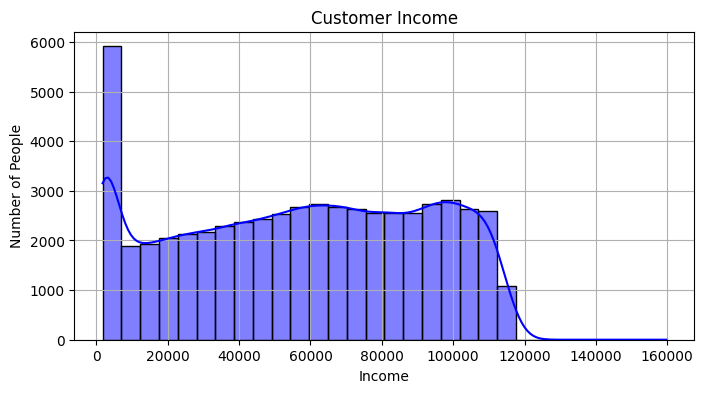

In [78]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Income'], bins=30, kde=True, color='Blue')
plt.title('Customer Income')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.grid(True)
plt.show()

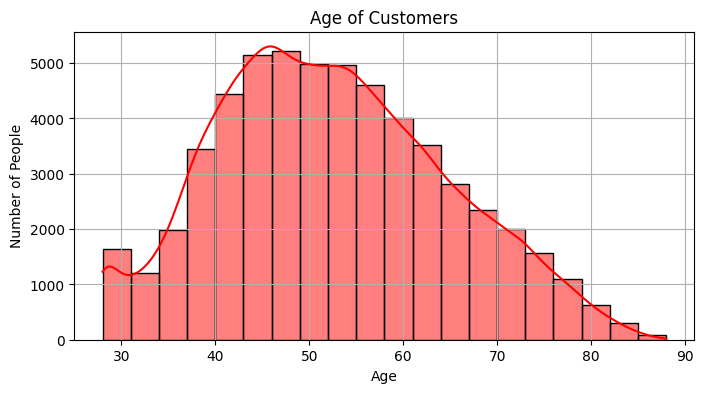

In [79]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='red')
plt.title('Age of Customers')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.grid(True)
plt.show()

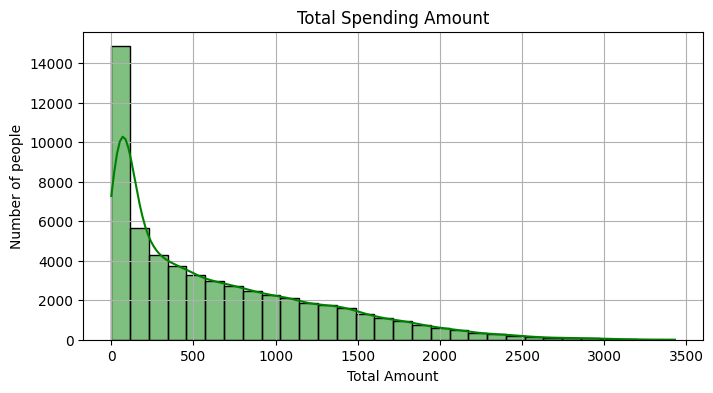

In [80]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Total_Amt'], bins=30, kde=True, color='green')
plt.title('Total Spending Amount')
plt.xlabel('Total Amount')
plt.ylabel('Number of people')
plt.grid(True)
plt.show()

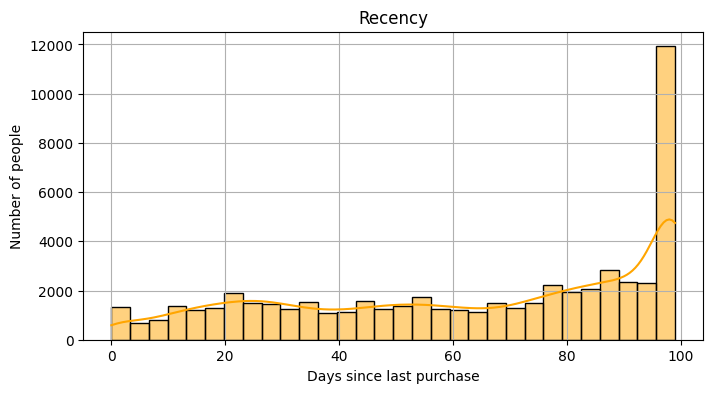

In [81]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Recency'], bins=30, kde=True, color='orange')
plt.title('Recency')
plt.xlabel('Days since last purchase')
plt.ylabel('Number of people')
plt.grid(True)
plt.show()

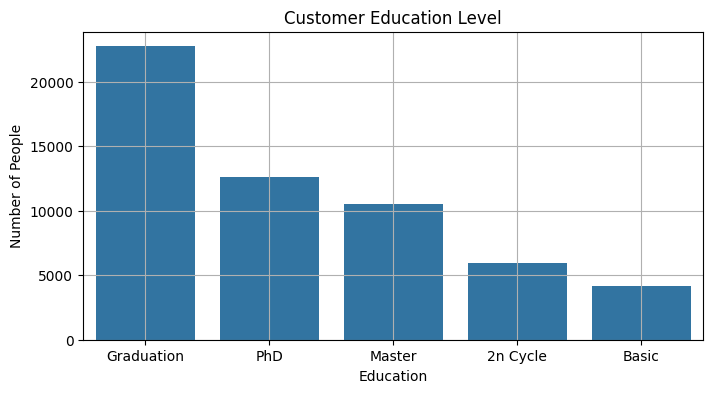

In [82]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Education', order=df['Education'].value_counts().index)
plt.title('Customer Education Level')
plt.xlabel('Education')
plt.ylabel('Number of People')
plt.grid(True)
plt.show()

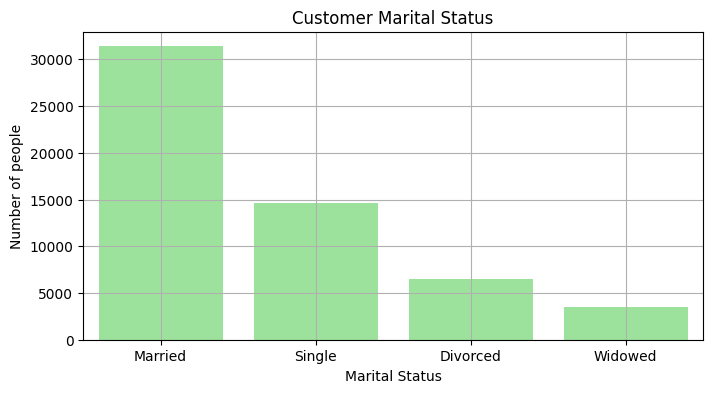

In [83]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Marital_Status', order=df['Marital_Status'].value_counts().index, color='lightgreen')
plt.title('Customer Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of people')
plt.grid(True)
plt.show()

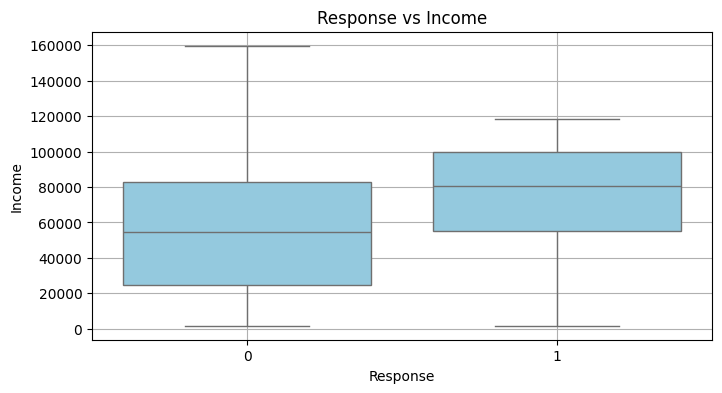

In [84]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='Income',color='skyblue')
plt.title('Response vs Income')
plt.xlabel('Response')
plt.ylabel('Income')
plt.grid(True)
plt.show()

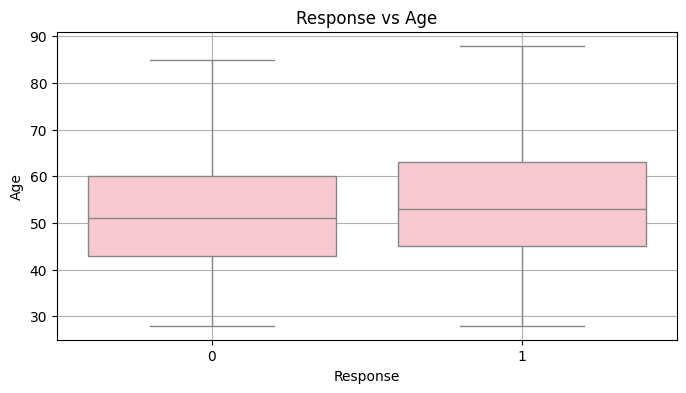

In [85]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='Age', color='pink', showfliers=False)
plt.title('Response vs Age')
plt.xlabel('Response')
plt.ylabel('Age')
plt.grid(True)
plt.show()

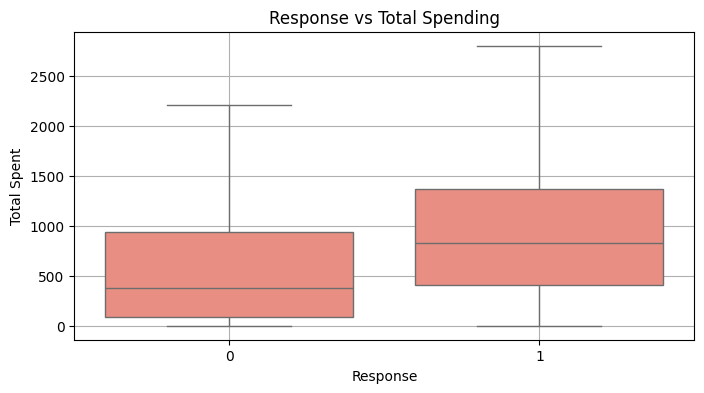

In [86]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='Total_Amt', color='salmon', showfliers=False)
plt.title('Response vs Total Spending')
plt.xlabel('Response')
plt.ylabel('Total Spent')
plt.grid(True)
plt.show()

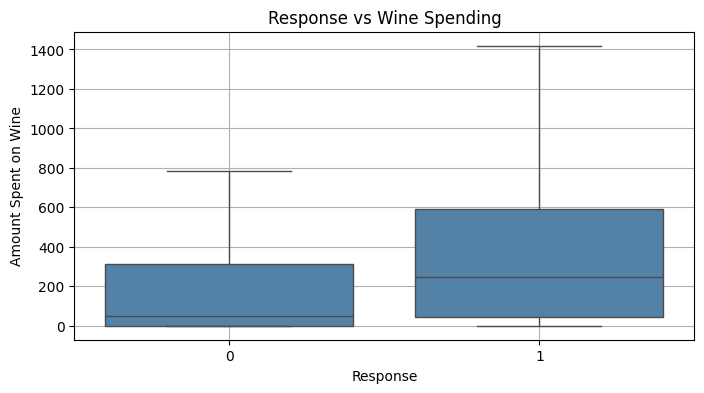

In [87]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='MntWines', color='steelblue',showfliers= False)
plt.title('Response vs Wine Spending')
plt.xlabel('Response')
plt.ylabel('Amount Spent on Wine')
plt.grid(True)
plt.show()

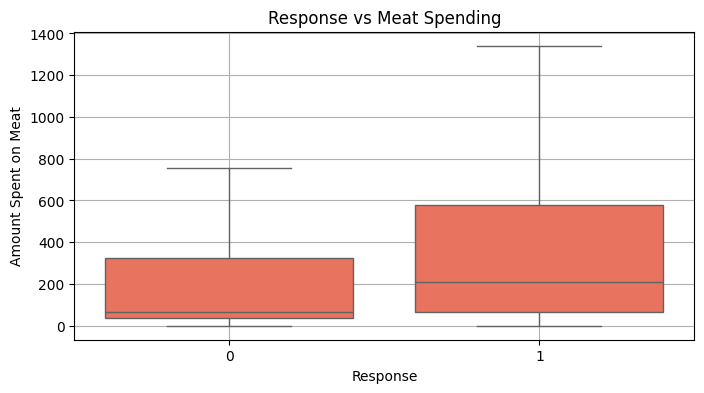

In [88]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='MntMeatProducts', color='tomato',showfliers= False)
plt.title('Response vs Meat Spending')
plt.xlabel('Response')
plt.ylabel('Amount Spent on Meat')
plt.grid(True)
plt.show()

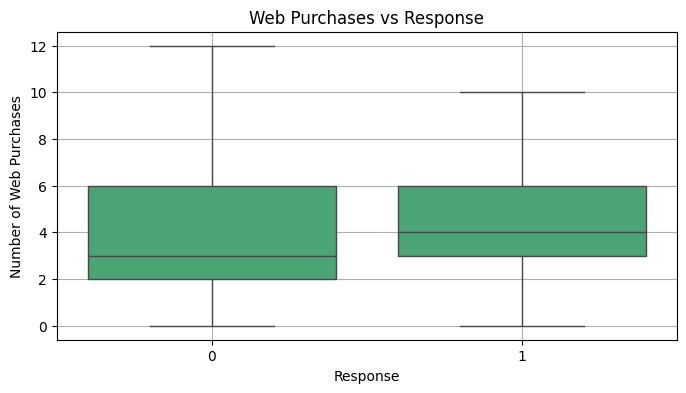

In [89]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='NumWebPurchases', color='mediumseagreen',showfliers=False)
plt.title('Web Purchases vs Response')
plt.xlabel('Response')
plt.ylabel('Number of Web Purchases')
plt.grid(True)
plt.show()

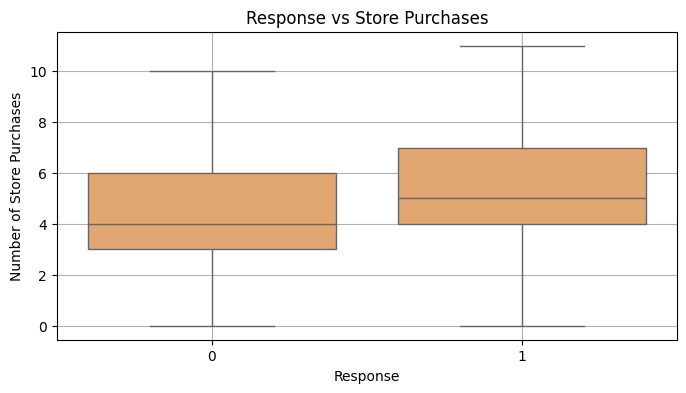

In [90]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='NumStorePurchases', color='sandybrown',showfliers=False)
plt.title('Response vs Store Purchases')
plt.xlabel('Response')
plt.ylabel('Number of Store Purchases')
plt.grid(True)
plt.show()

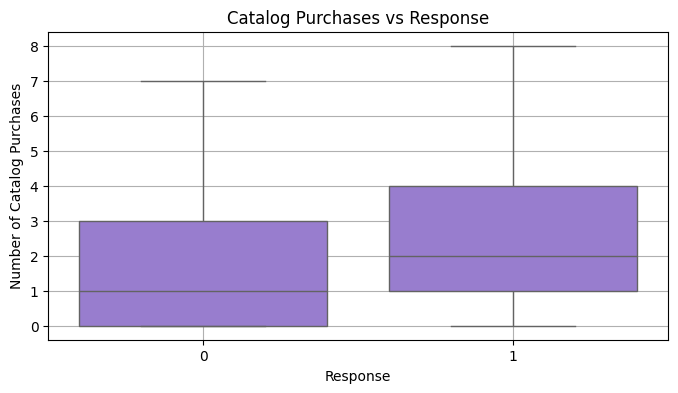

In [91]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Response', y='NumCatalogPurchases', color='mediumpurple',showfliers=False)
plt.title('Catalog Purchases vs Response')
plt.xlabel('Response')
plt.ylabel('Number of Catalog Purchases')
plt.grid(True)
plt.show()

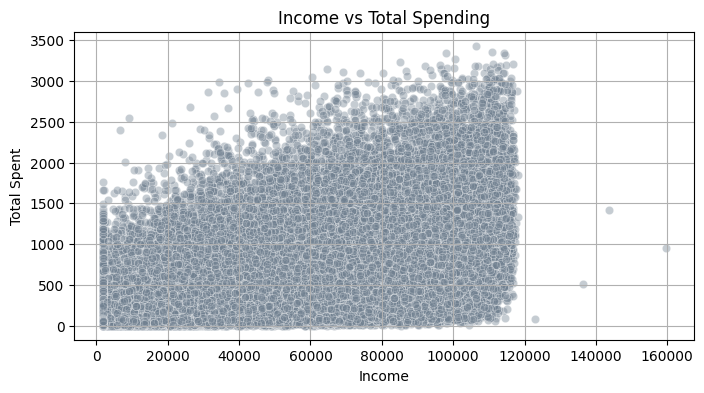

In [92]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Income', y='Total_Amt', color='slategray', alpha=0.4)
plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spent')
plt.grid(True)
plt.show()

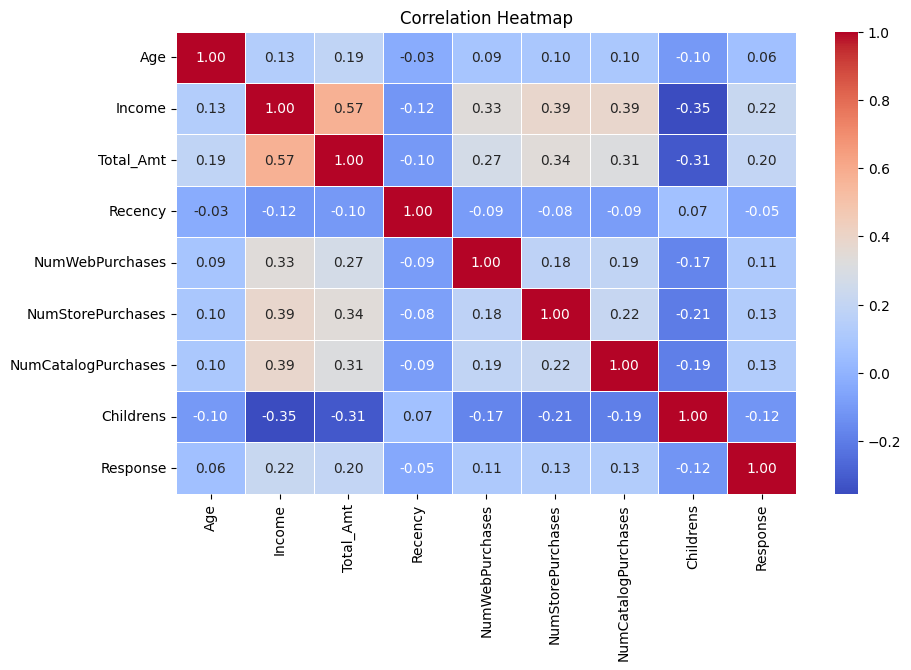

In [93]:
plt.figure(figsize=(10, 6))
cols = ['Age', 'Income','Total_Amt', 'Recency',
        'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases','Childrens' ,'Response']
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()